## Exploring META data and Generating Subfolders for FB_INF project

#### LOADING THE NECESSARY LIBRARIES TO EXPLORE THE METADATA GENERATED

In [14]:

%load_ext autoreload
%autoreload 2

from wormholes import *
from wormholes.perturb import *
from wormholes.tools.triplets_vis_tools import *
import matplotlib.pyplot as plt
import matplotlib.image as img
from argparse import Namespace
import os
import xarray as xr #this is to be able to read the .nc type of file
import shutil

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Set the HOME environment variable to your current working directory
os.environ["HOME"] = "/project/3018078.01/Gaziv/Wormholes_FB"

# Now the `os.path.expanduser("~")` will resolve to this directory
print(os.path.expanduser("~")) 

/project/3018078.01/Gaziv/Wormholes_FB


This next part of the script is loading the meta data file and does some exploration of the variables that have been defined there. 

In [16]:
#this is the directory where they will find the images (change as you deem necessary)
##TODO: check that it works with a different directory

# exp_root = f"{PROJECT_ROOT}/results/cache/gen_v4_OG_Paulos_replication"
exp_root = f"{PROJECT_ROOT}/results/cache/gen_v4"

# Load the metadata file
metadata = xr.open_dataset(f"{exp_root}/meta.nc")

# Print metadata structure
print(metadata)

# List variables in the dataset
#print(metadata.variables)

<xarray.Dataset>
Dimensions:                                   (image_id: 45360,
                                               class_index: 12,
                                               model_subject_name: 8)
Coordinates:
  * image_id                                  (image_id) object '694da0d19a75...
  * class_index                               (class_index) int64 0 1 ... 10 11
  * model_subject_name                        (model_subject_name) object 're...
Data variables: (12/15)
    model_name                                (image_id) object ...
    budget                                    (image_id) float64 ...
    n_iter                                    (image_id) int64 ...
    step_size                                 (image_id) float64 ...
    interp_alpha                              (image_id) float64 ...
    target_class_name                         (image_id) object ...
    ...                                        ...
    budget_usage                             

I am now transforming the .nc file into a Pandas dataframe, as this is the type of structure I am familiar with and allows me to do the selection of relevant information I need for my experiment

In [17]:
#Depending on the size of the meta.nc file. The kernel might get overwhemled when trying to trasnform it to a pandas dataframe. 
#Therefore, the next couple of code lines are to only pass the information that is relevant (reducing the size of df)
selected_vars = ["model_name", "budget", "image_id",'class_index', 'pred_logit',
                 'model_subject_name', 'orig_class_name', 'orig_name']
df = metadata[selected_vars].to_dataframe().reset_index()

# Convert the dataset to a Pandas DataFrame (this is because I am most comfortable using Pandas df)
# df = metadata.to_dataframe().reset_index()

# Inspect the metadata structure
print(df.head())

# Inspect the columns in the Pandas Dataframe
print(df.columns)

#information about the data in the columns
df.info(verbose=False)

                               image_id  class_index  \
0  694da0d19a75fd685ed4e37a32f90000.png            0   
1  694da0d19a75fd685ed4e37a32f90000.png            0   
2  694da0d19a75fd685ed4e37a32f90000.png            0   
3  694da0d19a75fd685ed4e37a32f90000.png            0   
4  694da0d19a75fd685ed4e37a32f90000.png            0   

                      model_subject_name                          model_name  \
0     resnet50_robust_mapped_RIN_l2_10_0  resnet50_robust_mapped_RIN_l2_10_0   
1  resnet50_robust_mapped_RIN_l2_10_0_v2  resnet50_robust_mapped_RIN_l2_10_0   
2      resnet50_robust_mapped_RIN_l2_1_0  resnet50_robust_mapped_RIN_l2_10_0   
3   resnet50_robust_mapped_RIN_l2_1_0_v2  resnet50_robust_mapped_RIN_l2_10_0   
4      resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_10_0   

   budget  pred_logit orig_class_name  \
0     0.0    0.707197            frog   
1     0.0    1.119270            frog   
2     0.0         NaN            frog   
3     0.0    3.224

I am now filtering the dataframe so it only includes the parameters that are relevant for my experiment. 
With the filtered data frame I can then create folders with the relevant images for the experiment (with the correct names)

NOTE: model_name is the variable used to define which model is being used to generate the adversarial images. model_subject_name is all the other models that will be tested on the adversarial images generated by model_name and compare their performances. 

In [18]:
#The following lines of code are ways of probing the df. Not necessary, but useful

# print(df['model_name'].unique()) # displays all the networks available to extract images from
# print(df['model_subject_name'].unique()) #the v2 versions of the networks are just initialized using different seeds
# print(df['budget'].unique()) #all the budget options I can select images from


# Apply filtering: model_name = 'resnet50_robust_mapped_RIN_l2_3_0', budget = '20'. Change this to whatever values you want

filtered_df = df[(df['model_name'] == 'resnet50_robust_mapped_RIN_l2_3_0') & (df['budget'] == 10) & (df['model_subject_name'] == 'resnet50_robust_mapped_RIN_l2_3_0')] 
print(filtered_df.head())
# print(filtered_df.columns)
# print(filtered_df['model_name'])
# print(len(filtered_df['image_id'].unique()))
filtered_df.shape
print(filtered_df['class_index'].unique())

#Code to visualize any image we want on the dataset
# im = img.imread(f"{exp_root}/images/30a0f974d91cf438f69c726c9434678b.png")
# plt.imshow(im)


                                     image_id  class_index  \
2764804  c7a2b269ac57843e818fa7f12df088a1.png            0   
2764812  c7a2b269ac57843e818fa7f12df088a1.png            1   
2764820  c7a2b269ac57843e818fa7f12df088a1.png            2   
2764828  c7a2b269ac57843e818fa7f12df088a1.png            3   
2764836  c7a2b269ac57843e818fa7f12df088a1.png            4   

                        model_subject_name                         model_name  \
2764804  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
2764812  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
2764820  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
2764828  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
2764836  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   

         budget  pred_logit orig_class_name  \
2764804    10.0    1.487902            frog   
2764812    10.0    1.775135            frog   

In the code above, the filtered_df now consists of only rows with 9 classes x 30 images x which of the 9 classes the current image is classified as (this information might be relevant then to probe whether certain classes are more likely to be transformed into other classes). I should ask Lea about this. 

I will create a histogram per class to see the distribution of the selected classes and assess whether there is any detected systematicity in the PGD


=== max_class_per_image for bear ===
                                     image_id  class_index
2809476  002fb0354b338fef7adbcec9b3e018cc.png            4
2806468  0241007c2b3bbd79aba39c4ce37f12a2.png            0
2807044  0ca4a02cadc4ee057c15ba2b22d6acd7.png            0
2810156  10c00338973a9bc16f33027ddfdcffde.png            5
2809540  14956f70620713104d74841de0863c5e.png            0

=== counts for bear (before mapping) ===
0     38
4      4
5     12
6      1
8      2
9      1
10     1
11     1
Name: class_index, dtype: int64


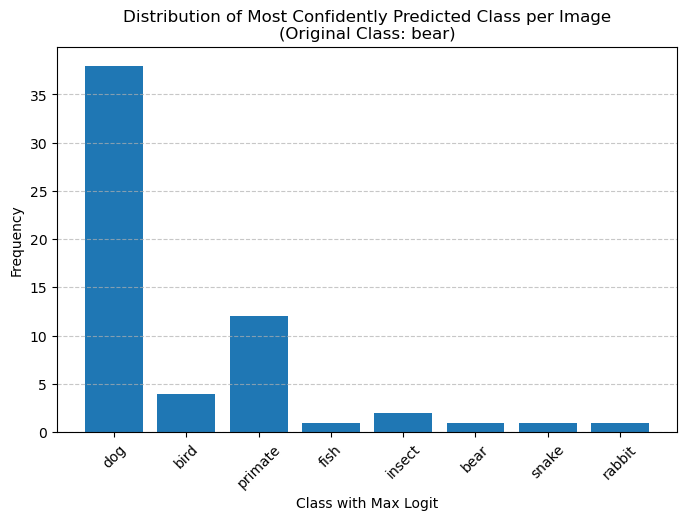


=== max_class_per_image for bird ===
                                     image_id  class_index
2783900  035b3ba03b3eae3f37ec8b04e9ee35fd.png           11
2784388  06d36fa69f11c510e5b17b69aebb48a4.png            0
2784540  099b54cb760cf3051fdf80bfd22a53c5.png            7
2782452  0b4bf1a061dda19b6b88203967dda081.png           10
2783084  23b2442c91e9400b8c82644a30687092.png            5

=== counts for bird (before mapping) ===
0     12
1      2
2      5
3      9
4      2
5      5
7      2
8     11
9      4
10     5
11     3
Name: class_index, dtype: int64


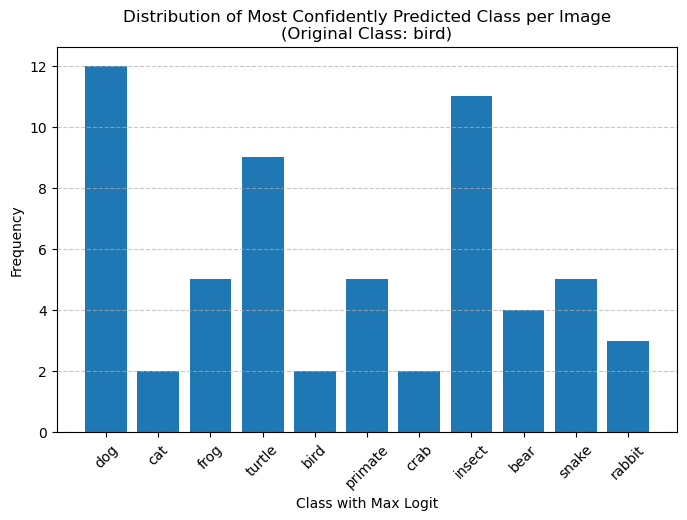


=== max_class_per_image for cat ===
                                     image_id  class_index
2803140  0ab1c5535e30825f5ff97beb3b90ce83.png            4
2801668  150a688950104d5315ff432e6cc583a1.png            0
2803908  158c717b28326997c8519e777d62ac9b.png            4
2803300  15c547bbfe104aa5d2c845d4f740b24f.png            0
2800612  16afe2dc7c5bb122a9c2cf5a2aa0d94b.png            0

=== counts for cat (before mapping) ===
0     38
1      2
3      2
4      3
5      8
8      1
9      1
10     2
11     3
Name: class_index, dtype: int64


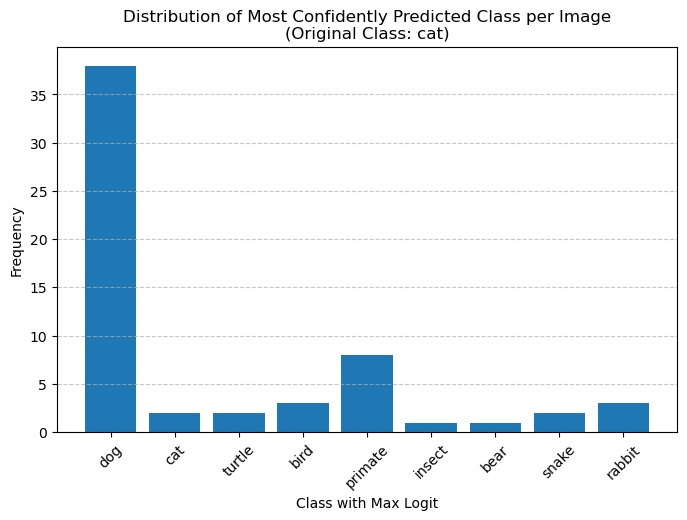


=== max_class_per_image for crab ===
                                     image_id  class_index
2788436  01df803f0c2a5214c5c214c553a766ef.png            2
2793284  0770904d41d0d59b270295907830efc2.png            8
2790148  0f2559695843152bdcc93959b5c1d7db.png            0
2792148  1edd2502bdca15b6cde41207ede1b58c.png           10
2790804  27ff8a2d1b7fdb280477d36cbfbca4c5.png           10

=== counts for crab (before mapping) ===
0      5
2      5
3      5
4      6
5      2
6      9
8     14
10    14
Name: class_index, dtype: int64


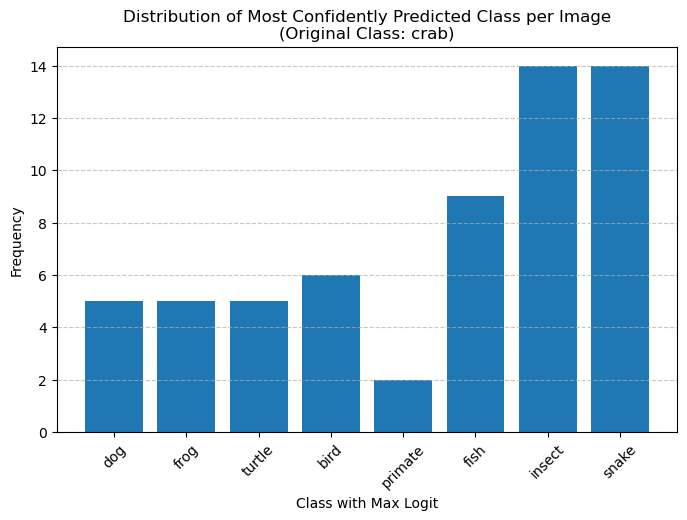


=== max_class_per_image for dog ===
                                     image_id  class_index
2797548  0225596528e61f90c128828558b41df9.png            1
2796476  0d9f0a154e1eb47bdcfa296cf4e331a8.png           11
2797644  14804e4f4edae02d3088fb692e205507.png            1
2795916  157b1221f292d7559e4b548e869d980a.png            1
2797356  1865ff9ba1e6be6e83ccf1d9d7d3dac3.png            1

=== counts for dog (before mapping) ===
0      2
1     31
3      3
4      6
5      6
8      1
9      3
10     4
11     4
Name: class_index, dtype: int64


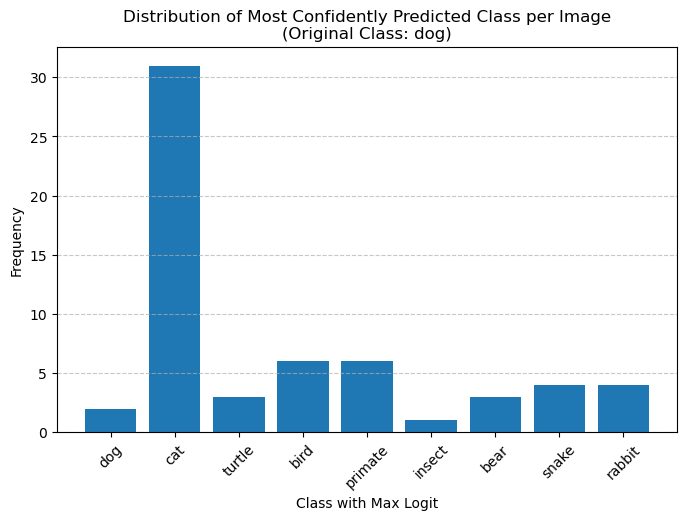


=== max_class_per_image for fish ===
                                     image_id  class_index
2829604  0151daf84b565389acf4dd0f926faa55.png            0
2832044  01e2e22b9fddb4a2d6efb84dfafffa58.png            5
2830140  098cc50839e61995b025a77de478c4dc.png            7
2833428  0be51ae47beb1df2529f37f07c1c1840.png           10
2831844  0c7dc0feba9e05fbb80e0bba17b3e849.png            4

=== counts for fish (before mapping) ===
0      7
2      1
3      8
4     14
5      5
6      4
7     11
8      3
10     7
Name: class_index, dtype: int64


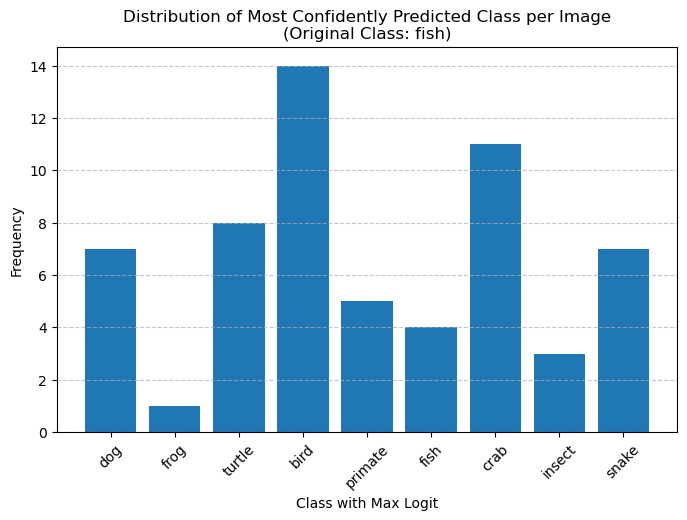


=== max_class_per_image for frog ===
                                     image_id  class_index
2767172  02e1e933fc40cc05abe9e7cc4f03c483.png            8
2767844  0882e2df9b3b765e0bf9868cc7f6b53d.png            8
2769956  0ed770376c891720b57e5f2f29026e5b.png            8
2768892  16ed41979c2212883d401df20ad5454a.png            7
2765812  18929a8211bdc2e7625595e06e64b0ca.png            6

=== counts for frog (before mapping) ===
0      1
3      7
4      2
6      3
7      5
8     22
10    19
11     1
Name: class_index, dtype: int64


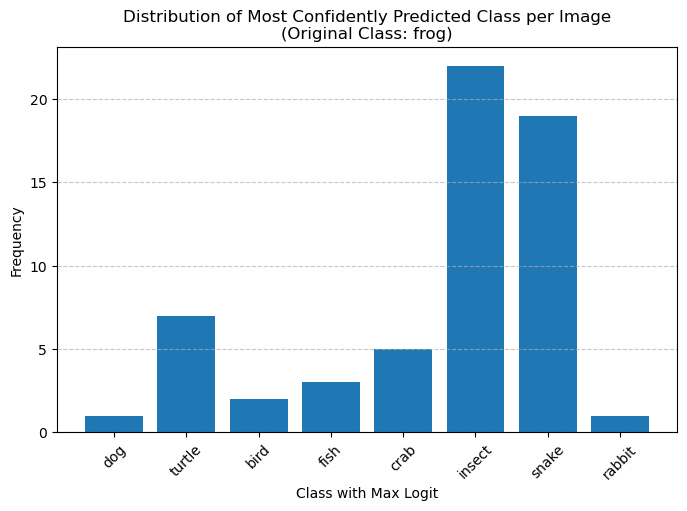


=== max_class_per_image for insect ===
                                     image_id  class_index
2814300  030ece74d256edfb898e4fb74f9a813f.png            7
2811420  1c719e0edcdf75c3be3078235281b4db.png            7
2815524  26dcf0af2e0ff63be470dbe5e8214579.png            4
2814972  29cdf4baa829b6b52c023eb7ce7e9eb9.png            7
2814372  29f482e81cadc4e9edf95e2b4d4e6714.png            4

=== counts for insect (before mapping) ===
0      2
2      5
3      1
4     20
6      3
7     17
8     10
10     2
Name: class_index, dtype: int64


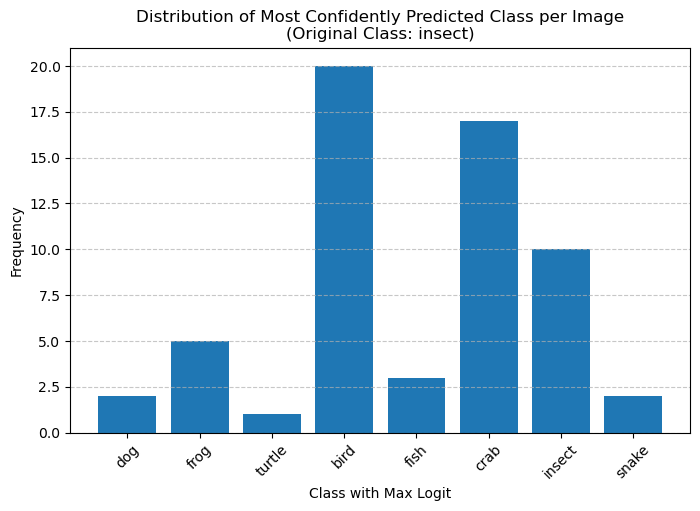


=== max_class_per_image for primate ===
                                     image_id  class_index
2826124  0304ae44e8bb7e8e433e89b1f5ac891b.png            9
2827748  050bee210439fc09a79cb8aa1a5e0aeb.png            8
2827652  0cb6b5051f20835703190af192db882d.png            8
2825860  13dd7a0a9e8976e8f31c84f1ee17c502.png            0
2826220  18535970d6f235e7bea5051228cb71ab.png            9

=== counts for primate (before mapping) ===
0     38
1      1
3      2
4      3
6      1
7      1
8      2
9     10
10     1
11     1
Name: class_index, dtype: int64


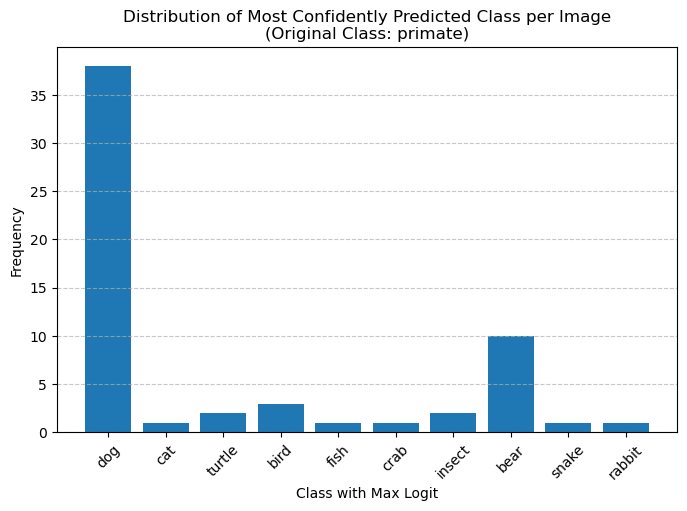


=== max_class_per_image for rabbit ===
                                     image_id  class_index
2817924  0028634b9e9c5d22bf8d7192da4440e6.png            4
2818148  07016feeb7df0818fa9bcfc0b4815c1c.png            8
2817388  0c88dcc95c0d26b145a83c54c100c9a2.png            9
2821620  1486300d57760529e98df2c05d8ab2da.png           10
2818884  15e7dcc2cadcde6875d70ee18dd46c68.png            4

=== counts for rabbit (before mapping) ===
0      7
1     13
3      1
4     18
5     10
7      1
8      5
9      1
10     4
Name: class_index, dtype: int64


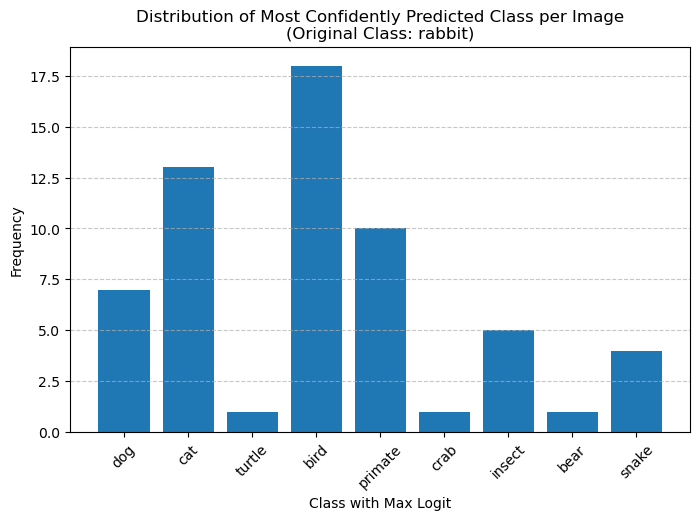


=== max_class_per_image for snake ===
                                     image_id  class_index
2779204  0428b9afd6554ef8e663122493f42f7b.png            0
2777220  05721dfb843cc3b168e53b22bb0a8d65.png            4
2781236  07aeeb8bffbec4c7e3be8f7718257ce1.png            2
2777916  086021ca287fc24f4b6eea254480978d.png            7
2778364  0acedc1cfdd21602b736039acad62d1a.png            3

=== counts for snake (before mapping) ===
0      4
1      2
2      4
3     10
4      7
6      4
7     12
8     12
10     4
11     1
Name: class_index, dtype: int64


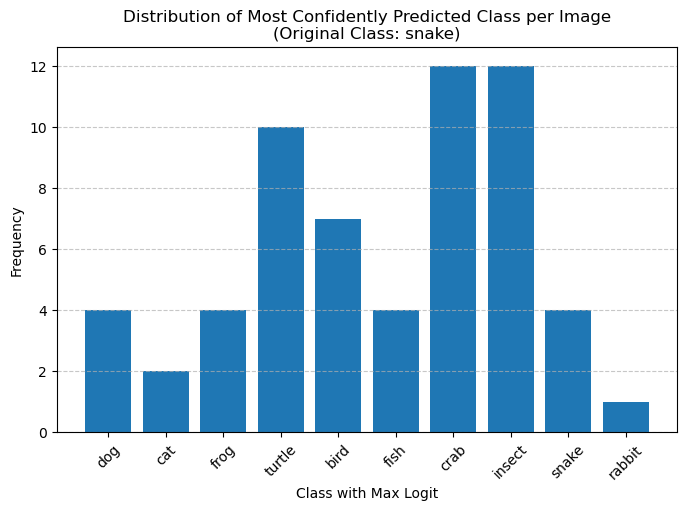


=== max_class_per_image for turtle ===
                                     image_id  class_index
2774180  01c0b1b394fbad6274debc543155dc13.png            8
2773684  04e42f72b0541335a96a959fc9a116ea.png            6
2771132  060f5c6c47b4b9d84aed7ca1db4262dd.png           11
2770804  067a03806138b60264ade91e9a2836e4.png            6
2772292  07ed338185daf585e64158827b9e4d2d.png            0

=== counts for turtle (before mapping) ===
0      5
2      2
4     19
5      4
6      8
7      7
8      9
9      1
10     4
11     1
Name: class_index, dtype: int64


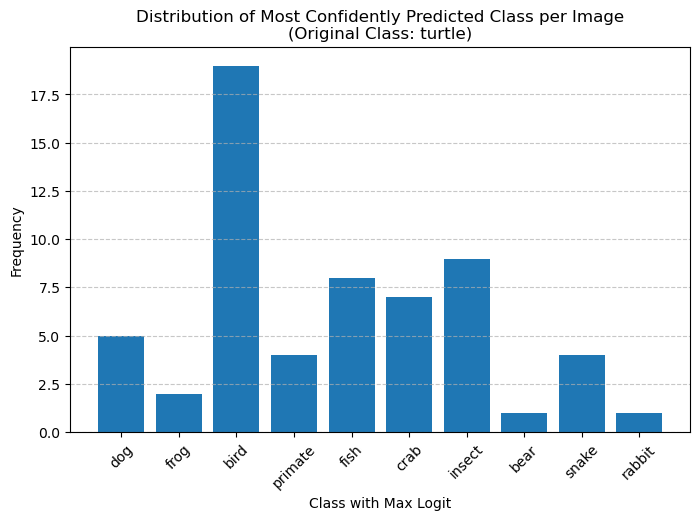

In [19]:

# Mapping of class_index to labels
# class_labels = {
#     0: "dog", 1: "cat", 2: "frog", 3: "turtle", 4: "bird",
#     5: "primate", 6: "fish", 7: "crab", 8: "insect"
# }

class_labels = { 0: 'dog', 1: 'cat', 
                   2: 'frog', 3: 'turtle', 4: 'bird', 
                   5: 'primate', 6: 'fish', 7: 'crab', 
                   8: 'insect', 9: 'bear', 10: 'snake', 11: 'rabbit'}


def plot_max_class_histogram_per_orig_class(df):
    """
    Plots histograms of the most frequently predicted class_index per image, separately for each orig_class_name.

    Parameters:
        df (pd.DataFrame): A DataFrame containing 'orig_class_name', 'image_id', 'class_index', and 'pred_logit'.

    Returns:
        None
    """
    # Loop over each original class
    for orig_class, sub_df in df.groupby("orig_class_name"):
        # Find the class_index with the highest pred_logit for each image
        max_class_per_image = sub_df.loc[sub_df.groupby("image_id")["pred_logit"].idxmax(), ["image_id", "class_index"]]

        # Print the DataFrame containing only the highest logit per image
        print(f"\n=== max_class_per_image for {orig_class} ===")
        print(max_class_per_image.head())  # Print first few rows to inspect

        # Count occurrences of each class_index being the max
        class_counts = max_class_per_image["class_index"].value_counts().sort_index()

        # Print the counts before mapping to class labels
        print(f"\n=== counts for {orig_class} (before mapping) ===")
        print(class_counts)

        # Map class_index to class labels
        class_labels_mapped = [class_labels[idx] for idx in class_counts.index]

        # Plot histogram
        plt.figure(figsize=(8, 5))
        plt.bar(class_labels_mapped, class_counts.values)
        plt.xlabel("Class with Max Logit")
        plt.ylabel("Frequency")
        plt.title(f"Distribution of Most Confidently Predicted Class per Image\n(Original Class: {orig_class})")
        plt.xticks(rotation=45)  # Rotate labels for readability
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()


plot_max_class_histogram_per_orig_class(filtered_df)


Now, I want to generate code that creates a new folder with all my perturbed images. 
I will devise a specific form of naming them that will make it easier for me to use in the actual experiment. 

naming convention = original/perturbed_imgclass_budget_imgnumber

I will create first an overall folder, then a folder with subfolders per each class (easier for manipulation of images)

I will then create a final folder with only the selected images

In [20]:
#Creating a new folder with images per class, renamed and easy for me to visualize and filter out later.

output_folder_root = "/project/3018078.01/FB_INF/stimulus_set"

def folder_per_class (df):
    """
    Generates folders in the output_folder_root for each of the Restricted ImageNet classes and provides a specific naming convention. 
    It has both the original image (taken from Imagenet validation set) as well as the perturbed image (budget defined above in the notebook)

    Parameters:
        df (pd.DataFrame): A DataFrame of the MetaData containing 'orig_class_name', 'image_id', 'class_index', and 'pred_logit'.
        If the notebook is being followed sequentially. This df should be the filtered df, using the filters desired.

    Returns:
        None

    Output:
        In the output_folder_root you should see your new folders with the images named according to the description:
        1. original_orig_class_name_budget_number -- for the original ilsrvc val dataset
        2. perturbed_orig_class_name_budget_number -- for the perturbed genv4 images

        number is just a numebr from image 0 to the maximum image generated
    """
    # Loop over each original class
    for orig_class, sub_df in df.groupby("orig_class_name"):
        #create a folder in the directory where I will store the images
        folder_dir_path = os.path.join(output_folder_root, str(orig_class))
        
        # Create the folder if it doesn't exist
        os.makedirs(folder_dir_path, exist_ok=True)
        sub_df = sub_df[sub_df['class_index'] == 0]

        for i, row in enumerate(sub_df.itertuples(index=False)):
              #create a file name (according to my naming convention) for perturbed images and cpy them to the output_folder_root
              file_name = f"perturbed_{row.orig_class_name}_{row.budget}_{i+1}.png"
              destination_path = os.path.join(folder_dir_path, file_name)
              source_path = os.path.join(exp_root, f'images/{row.image_id}')
              shutil.copy(source_path, destination_path)


              #create a file name (according to my naming convention) for the original images and copy them to the output_folder_root
              file_name_og = f"original_{row.orig_class_name}_{row.budget}_{i+1}.JPEG"
              destination_path_og = os.path.join(folder_dir_path, file_name_og)
              source_path_og = os.path.join(os.path.expanduser('~'), f'data/{row.orig_name}')
              shutil.copy(source_path_og, destination_path_og)

folder_per_class(filtered_df)

